In [2]:
import pandas as pd

candidatos = pd.DataFrame([
    {
        "direccion": "Avenida Paseo de la Reforma número 3, Colonia Guerrero, Código Postal 06300, Alcaldía Cuauhtémoc",
        "tramite": "enajenación a título gratuito",
        "latitud": 19.441448657779,
        "longitud": -99.14278899808845,
    },
    {
        "direccion": "calle Río Amazonas número 43, colonia Cuauhtémoc, Código Postal 06500, Alcaldía Cuauhtémoc",
        "tramite": "enajenación a título gratuito",
        "latitud": 19.431638855904733,
        "longitud": -99.16414530665138,
    },
    {
        "direccion": "Calle Xóchitl número 38, Pueblo San Pablo Tepetlapa, Código Postal 04620, Alcaldía Coyoacán",
        "tramite": "enajenación a título gratuito",
        "latitud": 19.320862697045204,
        "longitud":  -99.14026455181002,
    },
    {
        "direccion": "Calle Pedro Moreno número 109, Colonia Guerrero, Código Postal 06300, Alcaldía Cuauhtémoc",
        "tramite": "enajenación a título gratuito",
        "latitud": 19.441811176678424,
        "longitud": -99.14488376429779,
    },
    {
        "direccion": "Anillo Periférico s/n, Colonia San Felipe de Jesús, CP 07510, Alcaldía Gustavo A. Madero, CDMX",
        "tramite": "enajenación a título gratuito",
        "latitud": 19.50095556270164,
        "longitud": -99.07107715347753,
    },
    {
        "direccion": "Avenida Paseo de la Reforma, 213, Colonia Cuauhtémoc",
        "tramite": "adjudicación directa",
        "latitud": 19.430484801987696,
        "longitud": -99.16213594712531,
    },
    {
        "direccion": "Avenida Paseo de la Reforma, 211, Colonia Cuauhtémoc",
        "tramite": "adjudicación directa",
        "latitud": 19.430234217356077,
        "longitud": -99.1621986460901,
    },
    {
        "direccion": "Avenida Coyoacán Eje 3 Poniente 523, Colonia del Valle Centro, C.p. 03100",
        "tramite": "adjudicación directa",
        "latitud": 19.390292706434515,
        "longitud": -99.1665398301128,
    },
])

candidatos.to_csv("/Users/lucasgarcia/Desktop/Dataton/demanda_servicios_salud_cdmx/data/raw/indaabin/cdmx_geocodificado_manual.csv", index=False)

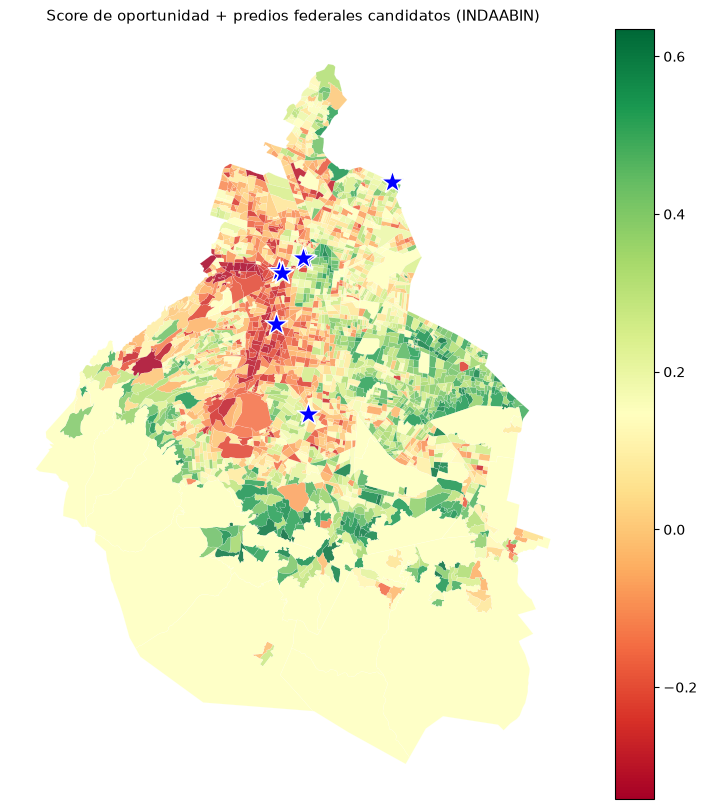

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Carga tus 8 predios candidatos
candidatos = pd.read_csv("/Users/lucasgarcia/Desktop/Dataton/demanda_servicios_salud_cdmx/data/raw/indaabin/cdmx_geocodificado_manual.csv")
candidatos_gdf = gpd.GeoDataFrame(
    candidatos,
    geometry=gpd.points_from_xy(candidatos["longitud"], candidatos["latitud"]),
    crs="EPSG:4326",
)

# 2. Tu tabla maestra de siempre
master = gpd.read_parquet("/Users/lucasgarcia/Desktop/Dataton/demanda_servicios_salud_cdmx/data/processed/tabla_maestra.parquet")

# 3. Mapa: score de oportunidad + los 8 predios encima, marcados distinto
fig, ax = plt.subplots(figsize=(10, 10))

master.plot(
    column="score_oportunidad",
    cmap="RdYlGn",
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.1,
    alpha=0.85,
)

candidatos_gdf.plot(
    ax=ax,
    marker="*",
    markersize=300,
    color="blue",
    edgecolor="white",
    linewidth=1,
    zorder=5,  # asegura que las estrellas queden encima del choropleth, no debajo
)

ax.set_axis_off()
ax.set_title("Score de oportunidad + predios federales candidatos (INDAABIN)", fontsize=11)
plt.show()